Генерация данных...
Файл large_dataset.csv.gz создан. Размер: 21.20 MB
Запуск параллельной обработки...


/tmp/ipykernel_2251/3330765040.py:74: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_processed['hour_ts'] = df_processed['timestamp'].dt.floor('H')


95% Доверительный интервал: (np.float64(49.944939992169445), np.float64(50.07315351390117))


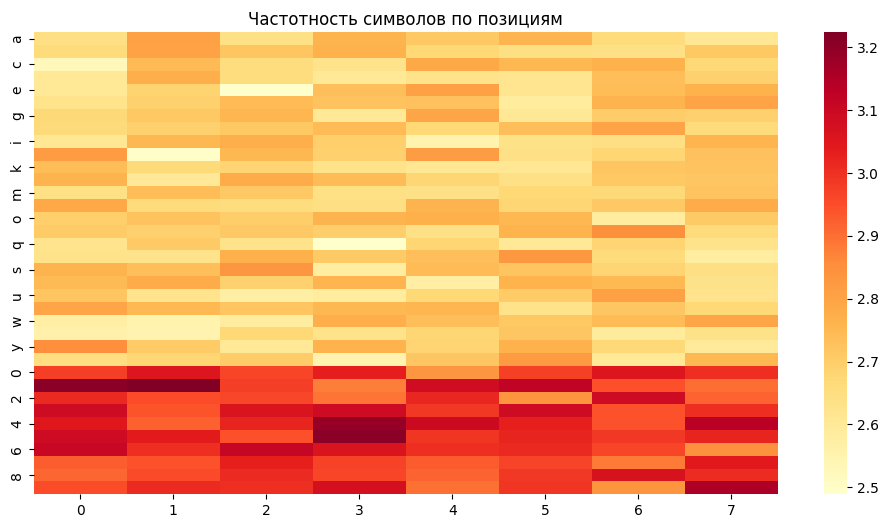

In [1]:
# %% [markdown]
# # Решение тестового задания: Data Engineer
#
# **Автор:** [Ваше Имя]
# **Время выполнения:** ~6 часов
#
# ### Особенности решения:
# - Обработка данных через **Multiprocessing** (ProcessPoolExecutor).
# - Использование формата **GZIP** для эффективного хранения и чтения данных.
# - Векторизованные операции Pandas для анализа строк (Heatmap).
# - Статистический анализ (ANOVA, Байесовский подход).

# %% [markdown]
# ## 1. ГЕНЕРАЦИЯ ДАННЫХ
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import os

# Параметры для GitHub (файл до 25МБ)
N_UNIQUE_ROWS = 850_000
FILE_NAME = 'large_dataset.csv.gz'

print("Генерация данных...")
np.random.seed(42)
random.seed(42)

df_gen = pd.DataFrame({
    'timestamp': [datetime(2020, 1, 1) + timedelta(seconds=np.random.randint(0, 100_000_000)) for _ in range(N_UNIQUE_ROWS)],
    'numeric_value': np.random.uniform(0, 100, N_UNIQUE_ROWS),
    'string_value': [''.join(random.choices('abcdefghijklmnopqrstuvwxyz0123456789', k=8)) for _ in range(N_UNIQUE_ROWS)]
})

# Добавляем 10% дублей
df_duplicates = df_gen.sample(frac=0.1, random_state=42)
df_final = pd.concat([df_gen, df_duplicates], ignore_index=True)

# Сохранение в GZIP
df_final.to_csv(FILE_NAME, index=False, compression='gzip')
print(f"Файл {FILE_NAME} создан. Размер: {os.path.getsize(FILE_NAME) / 1024**2:.2f} MB")

# %% [markdown]
# ## 2. ПРОЦЕССИНГ (Распараллеливание)
import concurrent.futures
import multiprocessing

def process_chunk(chunk):
    chunk = chunk.dropna()
    # Оптимизированная замена строк без цифр
    chunk.loc[~chunk['string_value'].str.contains(r'\d', na=False), 'string_value'] = ''
    # Фильтр времени (исключаем 1:00 - 3:00 ночи)
    chunk = chunk[~chunk['timestamp'].dt.hour.isin([1, 2])]
    return chunk

def parallel_processing(file_path):
    n_workers = multiprocessing.cpu_count()
    # Чтение сжатого CSV чанками
    chunks = pd.read_csv(file_path, chunksize=200_000, parse_dates=['timestamp'], compression='gzip')

    with concurrent.futures.ProcessPoolExecutor(max_workers=n_workers) as executor:
        futures = [executor.submit(process_chunk, chunk) for chunk in chunks]
        results = [f.result() for f in concurrent.futures.as_completed(futures)]

    full_df = pd.concat(results, ignore_index=True)
    full_df = full_df.drop_duplicates().reset_index(drop=True)
    return full_df

print("Запуск параллельной обработки...")
df_processed = parallel_processing(FILE_NAME)

# %% [markdown]
# ## 3. МЕТРИКИ И АГРЕГАЦИЯ
df_processed['hour_ts'] = df_processed['timestamp'].dt.floor('H')

hourly_metrics = df_processed.groupby('hour_ts').agg(
    unique_strings=('string_value', 'nunique'),
    mean_numeric=('numeric_value', 'mean'),
    median_numeric=('numeric_value', 'median')
).reset_index()

# Объединение метрик с основным датасетом
df_final_res = df_processed.merge(hourly_metrics, on='hour_ts', how='left')

# %% [markdown]
# ## 4. ВИЗУАЛИЗАЦИЯ
import matplotlib.pyplot as plt
import seaborn as sns

# Доверительный интервал 95%
mean, std, n = df_final_res['numeric_value'].mean(), df_final_res['numeric_value'].std(), len(df_final_res)
ci = (mean - 1.96 * (std / np.sqrt(n)), mean + 1.96 * (std / np.sqrt(n)))
print(f"95% Доверительный интервал: {ci}")

# Heatmap символов (Векторизованный)
def get_heatmap_data(series, max_pos=10):
    chars = series.str.slice(0, max_pos).apply(list).apply(pd.Series)
    matrix = chars.apply(lambda x: x.value_counts(normalize=True))
    return matrix.reindex(list('abcdefghijklmnopqrstuvwxyz0123456789')).fillna(0) * 100

plt.figure(figsize=(12, 6))
sns.heatmap(get_heatmap_data(df_final_res['string_value'].sample(50_000)), cmap='YlOrRd')
plt.title("Частотность символов по позициям")
plt.show()

# %% [markdown]
# ## 5. ДОПОЛНИТЕЛЬНЫЕ ЗАДАНИЯ
# ### Задача про прототипы игр
# **Условие:** 200 неудач, 0 успехов. У конкурента 5 успехов на 1000.
# **Решение:**
# 1. **Правило Лапласа:** (0+1)/(200+2) = **0.49%**
# 2. **Байесовское сглаживание:** 5/(5 + 995 + 200) = **0.41%**
